In [1]:
# Typing -> inbuilt python module, that makes it a tightly typed lang, like typscript.
# Annotated -> allows us to add metadata into our variables, e.g   age: Annotated[int, "Age in years"]
# TypeDict -> used to specify the schema of our state variable that langraph will use
from typing import Annotated, TypedDict


# StateGraph -> main class used to build langgraph, think of plain empty whiteboard.
# START -> predefined constant used to specify the beginning of the graph. Execution begins here. 
# END -> predefined constant. Tells langgraph to stop exectution here.
from langgraph.graph import StateGraph, START, END 

# add_messages -> used to push_back() messages to the state. if not present the state will be lost after each node execution. 
from langgraph.graph.message import add_messages



In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

### Creates the llm objects that our graph will use to generate responses.

1. Method of making our llm node

In [4]:
# ChatGroq -> langchain intregation package for Grok API
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")
print(llm.model)

llama-3.1-8b-instant


2. Method of making our llm node

In [5]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("llama-3.1-8b-instant", model_provider="groq")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10fc56350>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10fc56d50>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# Node Functionality
def chatbot(state: State):
    return {
        "messages" : [llm.invoke(state["messages"])]
    }

In [7]:
builder = StateGraph(State)

# Adding node to the graph
# first parameter -> node's ID
# second parameter -> actual node. we gave it chatbot and not chatbot() because we're telling langgraph here's the function and not run the function rn.
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# Compile for any erros and then build the graph in memory
graph = builder.compile()

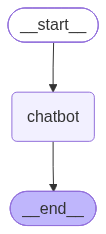

In [8]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
from langchain_core.messages import HumanMessage
res = graph.invoke({
    "messages" : [HumanMessage("Hi")]
})

res.pretty_print()

AttributeError: 'dict' object has no attribute 'pretty_print'

In [ ]:
for i in res["messages"] :
    i.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

It's nice to meet you. Is there something I can help you with or would you like to chat?


In [10]:
# Graph invoke send the llm response in one go, but stream send us the iterator of the chunks the llm using to answer
for event in graph.stream({"messages": [HumanMessage("Hi, how are you? write a 500 words essay ")]}):
    for value in event.values():
        print(value["messages"][-1].pretty_print())

================================== Ai Message ==================================

I'm functioning within the parameters set by my programming. I don't possess emotions, but I'm here to assist and provide information.

The Evolution of Human Connection in the Digital Age

The way people interact with one another has undergone a significant transformation in recent decades. The rise of digital technology has revolutionized the way we communicate, form relationships, and build communities. This shift has both positive and negative consequences, and it's essential to understand the complexities of human connection in the digital age.

One of the most significant changes brought about by the digital age is the way we form and maintain relationships. Social media platforms have made it easier for people to connect with others who share similar interests, values, and experiences. Online communities have sprung up around various topics, from hobbies and passions to social causes and support gr

### Chatbot with Tools

In [11]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(max_results=2)

search_tool.invoke("Who is naman nayak from chitkara university")

{'query': 'Who is naman nayak from chitkara university',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.namannayak.me',
   'title': 'Naman Nayak - Full Stack Developer',
   'content': "Search for a command to run... Full-Stack Developer@Google Developer Groups (GDG). I am Naman Nayak — a Full-Stack Developer and Research Scholar passionate about crafting impactful, scalable, and performance-driven web applications that merge technology with creativity. As aTechnical Executive at ACM Chitkara and Research Scholar with IEEE, I've built and led products that solve real-world challenges — from developing Quizify, a MERN-based examination platform serving 50+ students, to engineering Grainlyy, a blockchain-powered public distribution system improving transparency for 10,000+ beneficiaries. ### Google Developer Groups (GDG). • Contributing to full‑stack projects using modern technologies, including **React**, **Next.js**, and **TypeScript**. A

In [12]:
def multiply(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b

In [13]:
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

In [14]:
tools = [
    search_tool,
    multiply,
    add
]

In [15]:
# lets the llm know that these are the tools avaliable to it.
llm_with_tools = llm.bind_tools(tools)

In [16]:
# LLM node of the graph.
# `llm_with_tools` knows which tools are available because of `bind_tools()`.
# This node decides whether to answer directly or request a tool.
from langgraph.prebuilt import ToolNode
def assistant_node(state: State):
    return {
        "messages": [
            llm_with_tools.invoke(state["messages"])
        ]
    }


# Tool node of the graph.
# This node executes any tool requested by the LLM and
# adds the tool's result back to the graph state as a ToolMessage.
tool_node = ToolNode(tools)

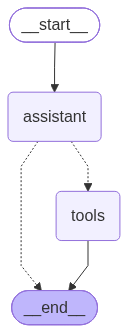

In [17]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Initialize the graph builder with the state schema
builder = StateGraph(State)

# Add nodes to the graph
builder.add_node("assistant", assistant_node)
builder.add_node("tools", tool_node)

# Define the execution flow
builder.add_edge(START, "assistant")

# After the assistant responds:
# - If it requested a tool, route to the ToolNode.
# - Otherwise, end the graph.
builder.add_conditional_edges(
    "assistant",
    tools_condition
)

# After executing the tool, end the graph.
# (For learning. Production agents usually loop back to "assistant".)
builder.add_edge("tools", END)

# Compile the graph into an executable graph
graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
from langchain_core.messages import HumanMessage
res = graph.invoke({
    "messages" : [HumanMessage("What's the recent ai news")]
})

for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (m6sxr14g0)
 Call ID: m6sxr14g0
  Args:
    query: Recent AI news
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.7890553, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "If we're having trouble keeping up with all the AI news this week, we can't imagine how you feel. The last three days have been a nonstop parade of new products, features, and frontier model releases from the leading AI l

In [19]:
res = graph.invoke({
    "messages" : [HumanMessage("What's 5 * 5")]
})

for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's 5 * 5
================================== Ai Message ==================================
Tool Calls:
  multiply (f0gwesm37)
 Call ID: f0gwesm37
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: multiply

25


In [20]:
res = graph.invoke({
    "messages" : [HumanMessage("What's the recent ai news and then multiply  5 by 10")]
})

for i in res["messages"]:
    i.pretty_print()

================================ Human Message =================================

What's the recent ai news and then multiply  5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (pk8a66n7w)
 Call ID: pk8a66n7w
  Args:
    query: recent ai news
    time_range: week
    topic: news
  multiply (zs23zztqh)
 Call ID: zs23zztqh
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/07/18/china-ai-open-source-kimi-anthropic-openai", "title": "AI race splits in two as China wages open-weight insurgency - Axios", "score": 0.67166495, "published_date": "Sat, 18 Jul 2026 12:46:11 GMT", "content": "Thinking Machines, a startup launched by former OpenAI CTO Mira Murati, made its highly anticipated debut this week with an open-we

### ReAct Architecture

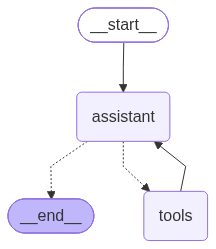

In [21]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Initialize the graph builder with the state schema
builder = StateGraph(State)

# Add nodes to the graph
builder.add_node("assistant", assistant_node)
builder.add_node("tools", tool_node)

# Define the execution flow
builder.add_edge(START, "assistant")

# After the assistant responds:
# - If it requested a tool, route to the ToolNode.
# - Otherwise, end the graph.
builder.add_conditional_edges(
    "assistant",
    tools_condition
)

# After executing the tool, end the graph.
# (For learning. Production agents usually loop back to "assistant".)
builder.add_edge("tools", "assistant")

# Compile the graph into an executable graph
graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
res = graph.invoke({
    "messages" : [HumanMessage("Give me the recent ai news and then multiply 5 by 10")]
})

for i in res["messages"]:
    i.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (b4mdvjhne)
 Call ID: b4mdvjhne
  Args:
    query: recent AI news
    time_range: month
    topic: news
  multiply (nfq5pskxm)
 Call ID: nfq5pskxm
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.7890553, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "If we're having trouble keeping up with all the AI news this week, we can't imagine how you feel. The last three days have b

### Adding memory to the agent

In [ ]:
res = graph.invoke({
    "messages" : [HumanMessage("Hello, my name is Naman")]
})
for i in res["messages"]:
    i.pretty_print()

================================ Human Message =================================

Hello, my name is Naman
================================== Ai Message ==================================

Hello Naman, it's nice to meet you! Is there something I can help you with today?


In [ ]:
res = graph.invoke({
    "messages" : [HumanMessage("What is my name?")]
})
for i in res["messages"]:
    i.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. If you'd like to share it with me, I'd be happy to chat with you about it.


In [23]:
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [24]:
def assistant_node(state: State):
    return {
        "messages" : [llm_with_tools.invoke(state["messages"])]
    }

tools_node = ToolNode(tools)

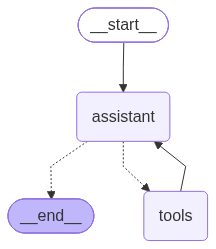

In [ ]:
builder = StateGraph(State)
builder.add_node("assistant", assistant_node)
builder.add_node("tools", tools_node)

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
config = {
    "configurable" : {
        "thread_id" : "1"
    }
}

res = graph.invoke(
    {
        "messages" : [HumanMessage("Hi, my name is Naman")],
    },
    config = config
)

for i in res["messages"]:
    i.pretty_print()

================================ Human Message =================================

Hi, my name is Naman
================================== Ai Message ==================================

Hello Naman, how can I assist you today?
================================ Human Message =================================

Hi, my name is Naman
================================== Ai Message ==================================

It looks like you mentioned your name twice. Is there something else I can help you with?
================================ Human Message =================================

Hi, my name is Naman
================================== Ai Message ==================================

You already mentioned your name earlier. What would you like to talk about or ask about today?
================================ Human Message =================================

Hi, my name is Naman
================================== Ai Message ==================================

You've mentioned your name three t

In [32]:
res = graph.invoke(
    {
        "messages" : [HumanMessage("Hi, what is my name")],
    },
    config = config
)

for i in res["messages"]:
    i.pretty_print()

================================ Human Message =================================

Hi, my name is Naman
================================== Ai Message ==================================

Hello Naman, how can I assist you today?
================================ Human Message =================================

Hi, my name is Naman
================================== Ai Message ==================================

It looks like you mentioned your name twice. Is there something else I can help you with?
================================ Human Message =================================

Hi, my name is Naman
================================== Ai Message ==================================

You already mentioned your name earlier. What would you like to talk about or ask about today?
================================ Human Message =================================

Hi, my name is Naman
================================== Ai Message ==================================

You've mentioned your name three t

### Streaming in graph


Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [34]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph.stream({"messages" : [HumanMessage("Hi, my name is Naman. I like to play badminton.")]},config,stream_mode="updates"):
    print(chunk)

{'assistant': {'messages': [AIMessage(content="It's nice to meet you, Naman. Badminton is a fun sport, do you play competitively or just for recreation?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1821, 'total_tokens': 1850, 'completion_time': 0.057055201, 'completion_tokens_details': None, 'prompt_time': 0.12235875, 'prompt_tokens_details': None, 'queue_time': 0.054926148, 'total_time': 0.179413951}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f889a-90c8-7802-9747-f0c891162379-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1821, 'output_tokens': 29, 'total_tokens': 1850})]}}


In [35]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph.stream({"messages" : [HumanMessage("Hi, my name is Naman. I like to play badminton.")]},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Naman. I like to play badminton.', additional_kwargs={}, response_metadata={}, id='cab5b1f2-2853-4d08-95a9-118a577d728c'), HumanMessage(content='Hi, my name is Naman. I like to play badminton.', additional_kwargs={}, response_metadata={}, id='b3fde248-c117-41f4-9fa1-74122d3f9dea'), AIMessage(content="It's nice to meet you, Naman. Badminton is a fun sport, do you play competitively or just for recreation?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1821, 'total_tokens': 1850, 'completion_time': 0.057055201, 'completion_tokens_details': None, 'prompt_time': 0.12235875, 'prompt_tokens_details': None, 'queue_time': 0.054926148, 'total_time': 0.179413951}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f889a-90c8-7802-9747-f0c891162379-0', too

In [39]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph.astream_events({"messages":[HumanMessage("Hi My name is Naman and I like to play football")]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Naman and I like to play football', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f889d-2cde-7fc2-a6e1-299eeae5cd74', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='b724ad28-0cb2-4c67-ac7d-b5cee731e8d1'), AIMessage(content="Nice to meet you, Krish! It sounds like you're a cricket enthusiast. Would you like to know some interesting facts about cricket or perhaps the latest cricket news? If so, I can try to find some information for you.", additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'model_provider': 'groq'}, i

### Human In the Loop